# 🛴 E-Scooter — Analyse descriptive
## Variable dépendante : `speed_kmh`

Ce notebook analyse le dataset filtré issu de la pipeline `build_clean_dataset.py`.  
Il couvre :
1. Chargement & aperçu des données  
2. Statistiques descriptives globales  
3. Distribution de la vitesse  
4. Vitesse × piétons (`n_pedestrians`)  
5. Vitesse × distance piéton (`distance_smooth_m`)  
6. Vitesse × largeur de route (`road_width_perp_m`)  
7. Vitesse × gyroscope / virage (`gyrz_deg_s`)  
8. Comparaison inter-trajets (`source`)  
9. Matrice de corrélation  
10. Vue synthétique — heatmap des moyennes par bin


## 1 · Imports & configuration

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

PALETTE   = sns.color_palette("crest", as_cmap=False)
COLOR_SPD = "#2E86AB"   # bleu vitesse
COLOR_ACC = "#511A1E"   # rouge accent

DATASET_PATH = "/Volumes/My Passport/clean_dataset.csv"   # ← adapter si besoin


## 2 · Chargement & aperçu

In [52]:
df = pd.read_csv(DATASET_PATH)

print(f"Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Trajets (source): {df['source'].nunique()}")
print(f"Frames uniques  : {df['frame'].nunique():,}")
print()
display(df.head(8))
print()
print("Types :")
display(df.dtypes.to_frame("dtype"))
print()
print("Valeurs manquantes :")
display(df.isna().sum().to_frame("n_missing"))


Dimensions     : 877,682 lignes × 25 colonnes
Trajets (source): 25
Frames uniques  : 4,922



,source,frame,track_id,user_type_yolo,distance_smooth_m,encounter_status,speed_kmh,gyrz_deg_s,n_pedestrians,road_width_perp_m,...,is_weekend,time_of_day,month,season,genre,age,experience,nb_trajets,distance_km,rider_id
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,38.189679,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,38.354068,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.730032,1,38.518458,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.205030,1,38.189679,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.205030,1,38.354068,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
5,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,21.205030,1,38.518458,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
6,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,17.040031,1,38.189679,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2
7,332t_2023-04-26 12_05_55_332t_21_27_22_15,201,23,pedestrian,12.954853,coded,11.76523,17.040031,1,38.354068,...,False,Morning,4,Spring,female,29.0,>2,57.0,241.603,332t_vague2



Types :


,dtype
source,object
frame,int64
track_id,int64
user_type_yolo,object
distance_smooth_m,float64
encounter_status,object
speed_kmh,float64
gyrz_deg_s,float64
n_pedestrians,int64
road_width_perp_m,float64



Valeurs manquantes :


,n_missing
source,0
frame,0
track_id,0
user_type_yolo,0
distance_smooth_m,0
encounter_status,0
speed_kmh,17964
gyrz_deg_s,17964
n_pedestrians,0
road_width_perp_m,19054


## 3 · Statistiques descriptives globales

In [53]:
num_cols = ["speed_kmh", "distance_smooth_m", "n_pedestrians",
            "road_width_perp_m", "gyrz_deg_s"]

desc = df[num_cols].describe(percentiles=[.10, .25, .50, .75, .90]).T
desc["cv_%"] = (desc["std"] / desc["mean"] * 100).round(1)
display(desc.round(3))


,count,mean,std,min,10%,25%,50%,75%,90%,max,cv_%
speed_kmh,859718.0,11.902,5.962,2.018,6.626,8.409,10.033,13.438,22.177,33.269,50.1
distance_smooth_m,877682.0,8.900,3.399,0.714,3.970,6.054,8.943,11.757,13.603,15.000,38.2
n_pedestrians,877682.0,5.333,3.148,1.000,2.000,3.000,5.000,7.000,10.000,15.000,59.0
road_width_perp_m,858628.0,19.605,13.601,0.037,7.191,9.788,18.749,23.300,36.322,103.719,69.4
gyrz_deg_s,859718.0,0.025,11.398,-68.320,-14.917,-7.280,0.067,7.585,14.800,70.017,45229.8


## 4 · Distribution de la vitesse

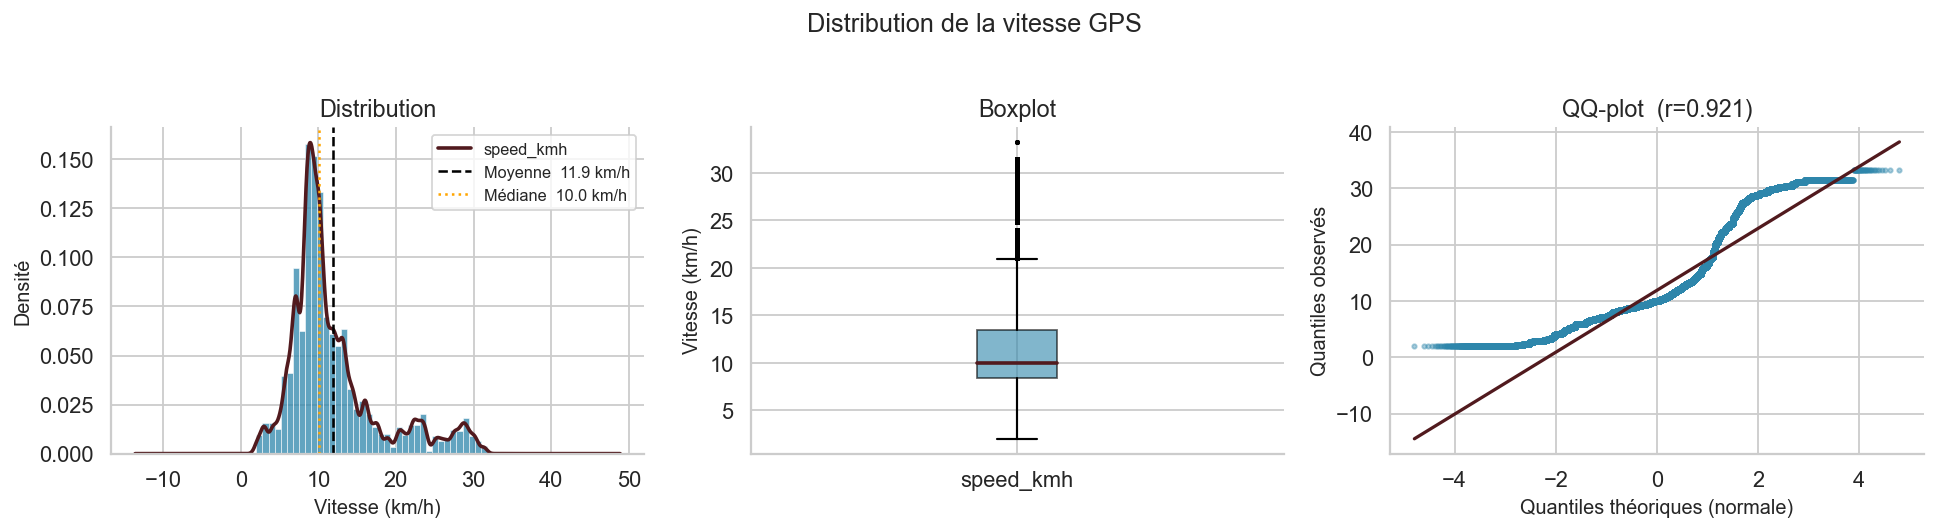

Shapiro-Wilk  W=0.8373  p=0.00e+00  → non-normale (α=0.05)
Skewness=1.446  |  Kurtosis=1.654


In [54]:
spd = df["speed_kmh"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 4a — Histogramme + KDE
ax = axes[0]
ax.hist(spd, bins=40, color=COLOR_SPD, alpha=0.75, density=True, edgecolor="white", lw=0.4)
spd.plot.kde(ax=ax, color=COLOR_ACC, lw=2)
ax.axvline(spd.mean(),   color="black",  lw=1.4, ls="--", label=f"Moyenne  {spd.mean():.1f} km/h")
ax.axvline(spd.median(), color="orange", lw=1.4, ls=":",  label=f"Médiane  {spd.median():.1f} km/h")
ax.set_xlabel("Vitesse (km/h)")
ax.set_ylabel("Densité")
ax.set_title("Distribution")
ax.legend(fontsize=9)

# 4b — Boxplot
ax = axes[1]
ax.boxplot(spd, vert=True, patch_artist=True,
           boxprops=dict(facecolor=COLOR_SPD, alpha=0.6),
           medianprops=dict(color=COLOR_ACC, lw=2),
           whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
           flierprops=dict(marker=".", markersize=3, alpha=0.3))
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Boxplot")
ax.set_xticklabels(["speed_kmh"])

# 4c — QQ-plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(spd, dist="norm")
ax.scatter(osm, osr, s=6, alpha=0.4, color=COLOR_SPD)
ax.plot(osm, slope * np.array(osm) + intercept, color=COLOR_ACC, lw=1.8)
ax.set_xlabel("Quantiles théoriques (normale)")
ax.set_ylabel("Quantiles observés")
ax.set_title(f"QQ-plot  (r={r:.3f})")

plt.suptitle("Distribution de la vitesse GPS", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Test de normalité
stat, p = stats.shapiro(spd.sample(min(5000, len(spd)), random_state=42))
print(f"Shapiro-Wilk  W={stat:.4f}  p={p:.2e}  → {'non-normale' if p < 0.05 else 'normale'} (α=0.05)")
skew = spd.skew()
kurt = spd.kurtosis()
print(f"Skewness={skew:.3f}  |  Kurtosis={kurt:.3f}")


## 5 · Vitesse × nombre de piétons

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/1838757636.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="n_ped_cat", y="speed_kmh", order=order,


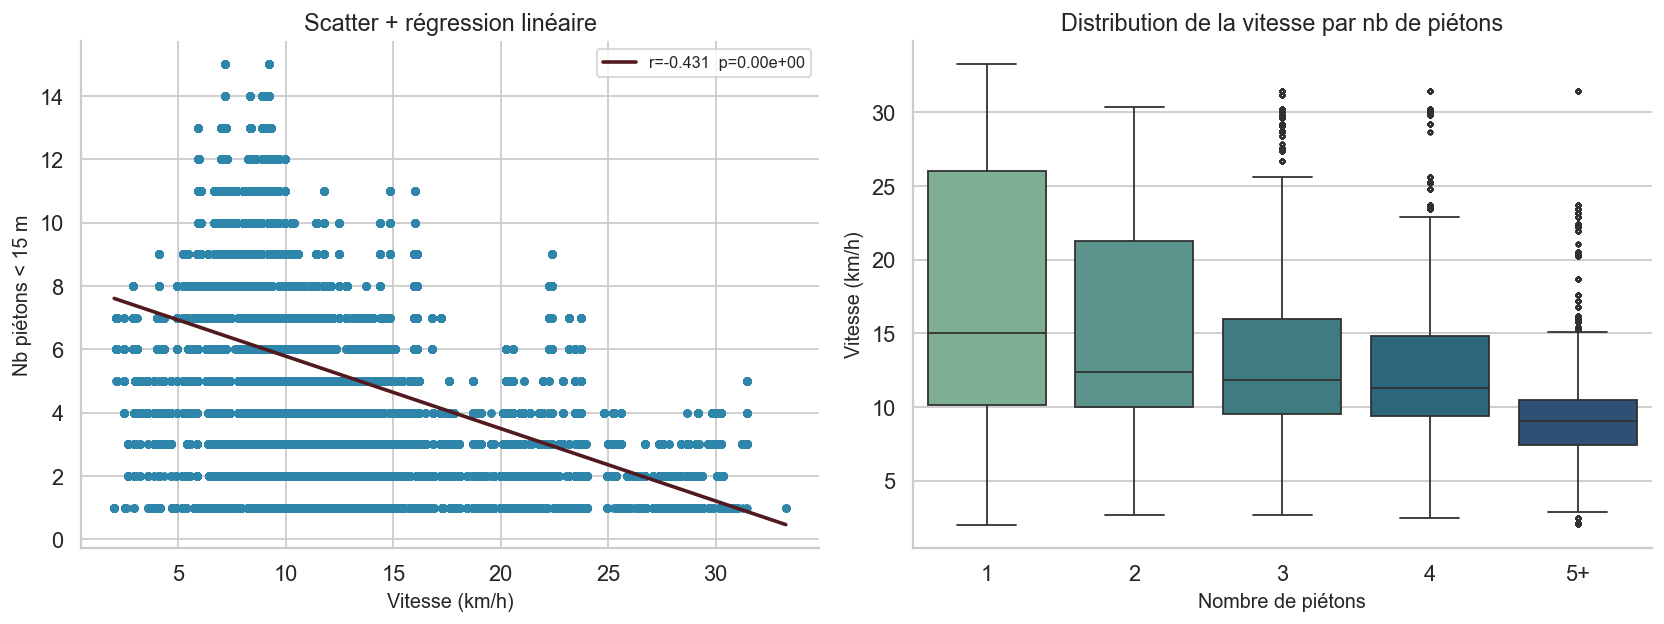

ANOVA one-way  F=16767.39  p=0.00e+00


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 5a — Scatter + régression
ax = axes[0]
sub = df[["speed_kmh", "n_pedestrians"]].dropna()
ax.scatter(sub["speed_kmh"], sub["n_pedestrians"],
           alpha=0.25, s=12, color=COLOR_SPD)
m, b, r, p, se = stats.linregress(sub["speed_kmh"], sub["n_pedestrians"])
x_line = np.linspace(sub["speed_kmh"].min(), sub["speed_kmh"].max(), 200)
ax.plot(x_line, m * x_line + b, color=COLOR_ACC, lw=2,
        label=f"r={r:.3f}  p={p:.2e}")
ax.set_xlabel("Vitesse (km/h)")
ax.set_ylabel("Nb piétons < 15 m")
ax.set_title("Scatter + régression linéaire")
ax.legend(fontsize=9)

# 5b — Boxplot par nombre de piétons
ax = axes[1]
df["n_ped_cat"] = df["n_pedestrians"].clip(upper=5).astype(int).astype(str)
df["n_ped_cat"] = df["n_ped_cat"].replace({"5": "5+"})
order = [str(i) for i in range(1, 5)] + ["5+"]
order = [o for o in order if o in df["n_ped_cat"].unique()]
sns.boxplot(data=df, x="n_ped_cat", y="speed_kmh", order=order,
            palette="crest", ax=ax, flierprops={"markersize": 2, "alpha": 0.3})
ax.set_xlabel("Nombre de piétons")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Distribution de la vitesse par nb de piétons")

plt.tight_layout()
plt.show()

# ANOVA one-way
groups = [g["speed_kmh"].dropna().values
          for _, g in df.groupby("n_pedestrians")
          if len(g) > 5]
F, p_anova = stats.f_oneway(*groups)
print(f"ANOVA one-way  F={F:.2f}  p={p_anova:.2e}")


## 6 · Vitesse × distance au piéton

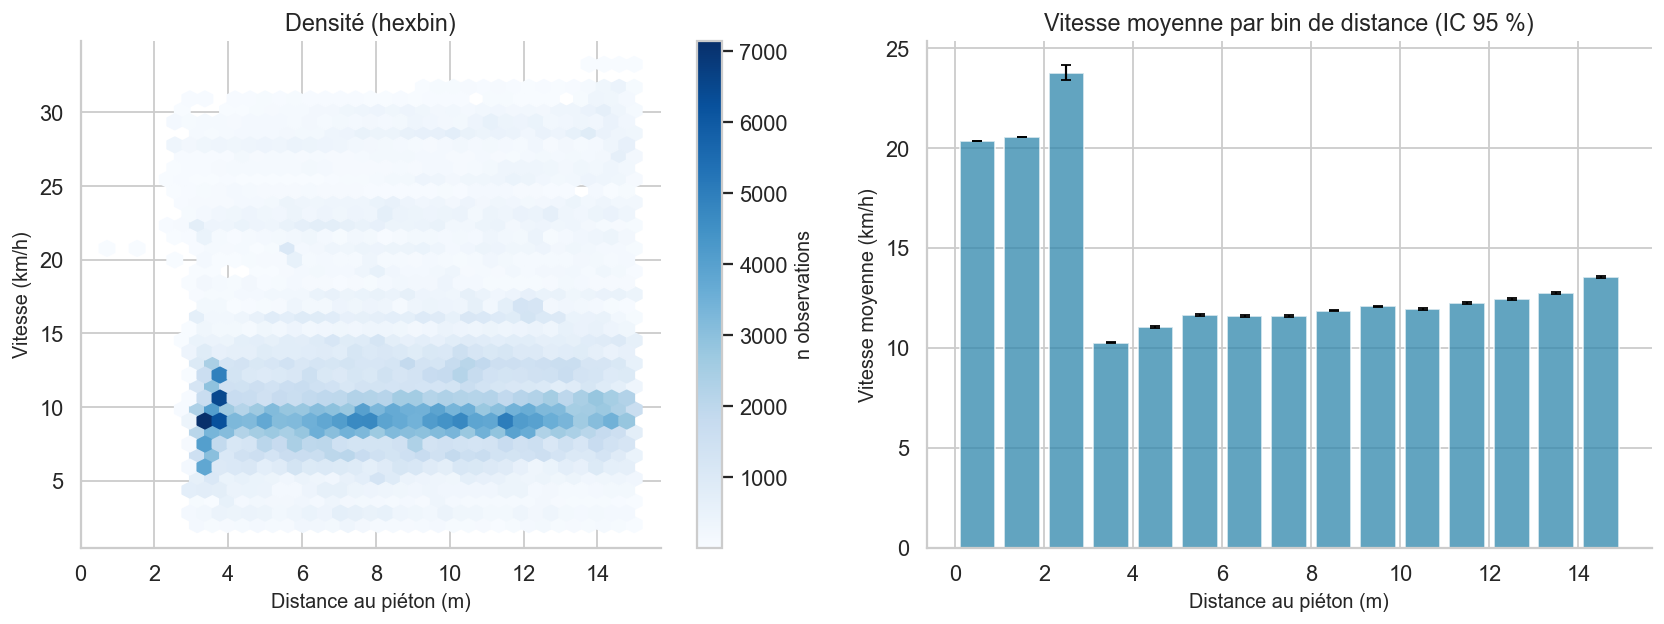

Pearson r=0.119  p=0.00e+00


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub = df[["speed_kmh", "distance_smooth_m"]].dropna()

# 6a — Hexbin
ax = axes[0]
hb = ax.hexbin(sub["distance_smooth_m"], sub["speed_kmh"],
               gridsize=35, cmap="Blues", mincnt=1)
plt.colorbar(hb, ax=ax, label="n observations")
ax.set_xlabel("Distance au piéton (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Densité (hexbin)")

# 6b — Moyenne de vitesse par bin de distance
ax = axes[1]
bins_dist = np.arange(0, 15.5, 1)
sub["dist_bin"] = pd.cut(sub["distance_smooth_m"], bins_dist)
grp = sub.groupby("dist_bin")["speed_kmh"].agg(["mean", "sem"]).dropna()
centers = [iv.mid for iv in grp.index]
ax.bar(centers, grp["mean"], width=0.8, color=COLOR_SPD, alpha=0.75)
ax.errorbar(centers, grp["mean"], yerr=grp["sem"] * 1.96,
            fmt="none", color="black", capsize=3, lw=1.2)
ax.set_xlabel("Distance au piéton (m)")
ax.set_ylabel("Vitesse moyenne (km/h)")
ax.set_title("Vitesse moyenne par bin de distance (IC 95 %)")

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sub["distance_smooth_m"], sub["speed_kmh"])
print(f"Pearson r={r:.3f}  p={p:.2e}")


## 7 · Vitesse × largeur de route

KeyboardInterrupt: 

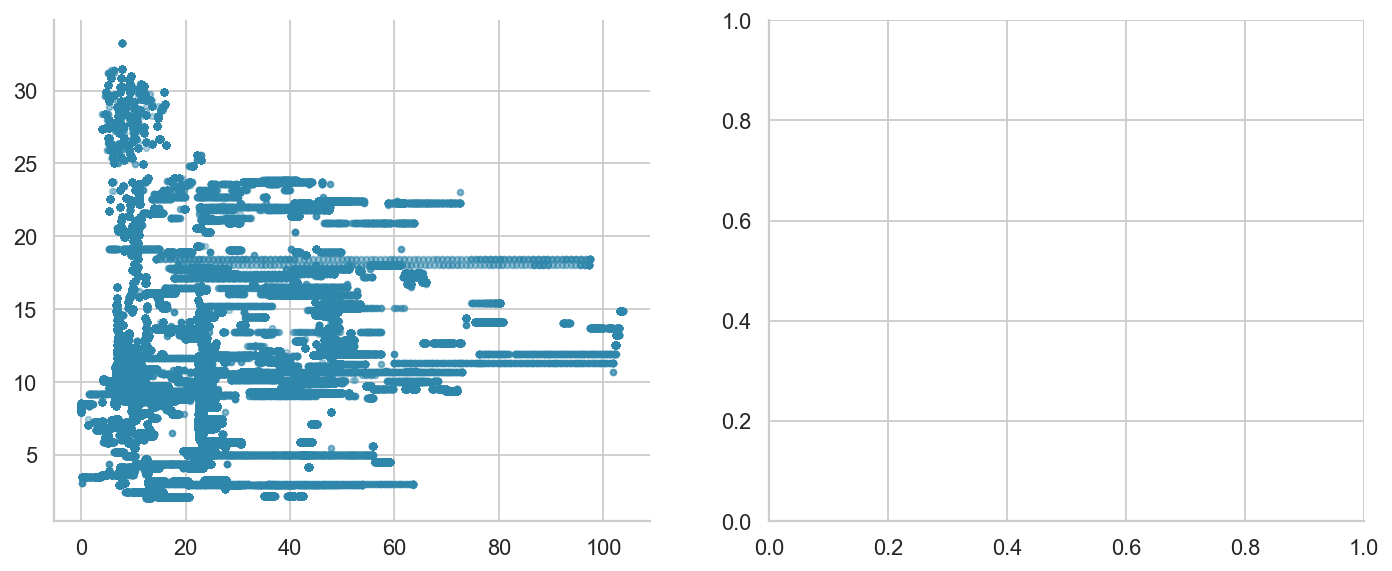

In [57]:
sub = df[["speed_kmh", "road_width_perp_m"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 7a — Scatter + LOWESS
ax = axes[0]
from statsmodels.nonparametric.smoothers_lowess import lowess
ax.scatter(sub["road_width_perp_m"], sub["speed_kmh"],
           alpha=0.2, s=10, color=COLOR_SPD)
lw_xy = lowess(sub["speed_kmh"], sub["road_width_perp_m"], frac=0.3)
ax.plot(lw_xy[:, 0], lw_xy[:, 1], color=COLOR_ACC, lw=2.5, label="LOWESS")
ax.set_xlabel("Largeur de route perpendiculaire (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Scatter + LOWESS")
ax.legend(fontsize=9)

# 7b — Bins de largeur
ax = axes[1]
bins_w = [0, 4, 6, 8, 10, 15, 999]
labels_w = ["0–4", "4–6", "6–8", "8–10", "10–15", ">15"]
sub["width_bin"] = pd.cut(sub["road_width_perp_m"], bins=bins_w, labels=labels_w)
sns.violinplot(data=sub, x="width_bin", y="speed_kmh",
               palette="crest", ax=ax, inner="quartile",
               order=labels_w)
ax.set_xlabel("Largeur de route (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Distribution de vitesse par largeur de route")

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sub["road_width_perp_m"], sub["speed_kmh"])
print(f"Pearson r={r:.3f}  p={p:.2e}")


## 9 · Comparaison inter-rider

Observations totales     : 877682
Riders uniques           : 15
Avec age renseigné       : 15
Avec experience renseigné: 15
Genres présents          : ['female' 'male']
       rider_id   genre   age  experience_num  nb_trajets  speed_mean
0   332t_vague2  female  29.0            3.00        57.0   11.789558
1   335t_vague2    male  55.0            3.00        24.0   26.343140
2   355t_vague1  female  37.0            1.50        68.0    9.100362
3   363t_vague2    male  27.0            3.00        50.0   10.831919
4   364t_vague2  female  53.0            3.00       108.0   10.649130
5   369t_vague2    male  21.0            0.75        75.0   19.544805
6   371t_vague3  female  53.0            0.25        28.0    9.420998
7   374t_vague2  female  23.0            1.50        52.0   13.084620
8   375t_vague1    male  49.0            0.25       120.0    5.493086
9   378t_vague1  female  30.0            0.25        14.0   10.752572
10  389t_vague2    male  21.0            3.00        70.0    

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/259983062.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="genre", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/259983062.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="genre", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/259983062.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="exp_bin", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/259983

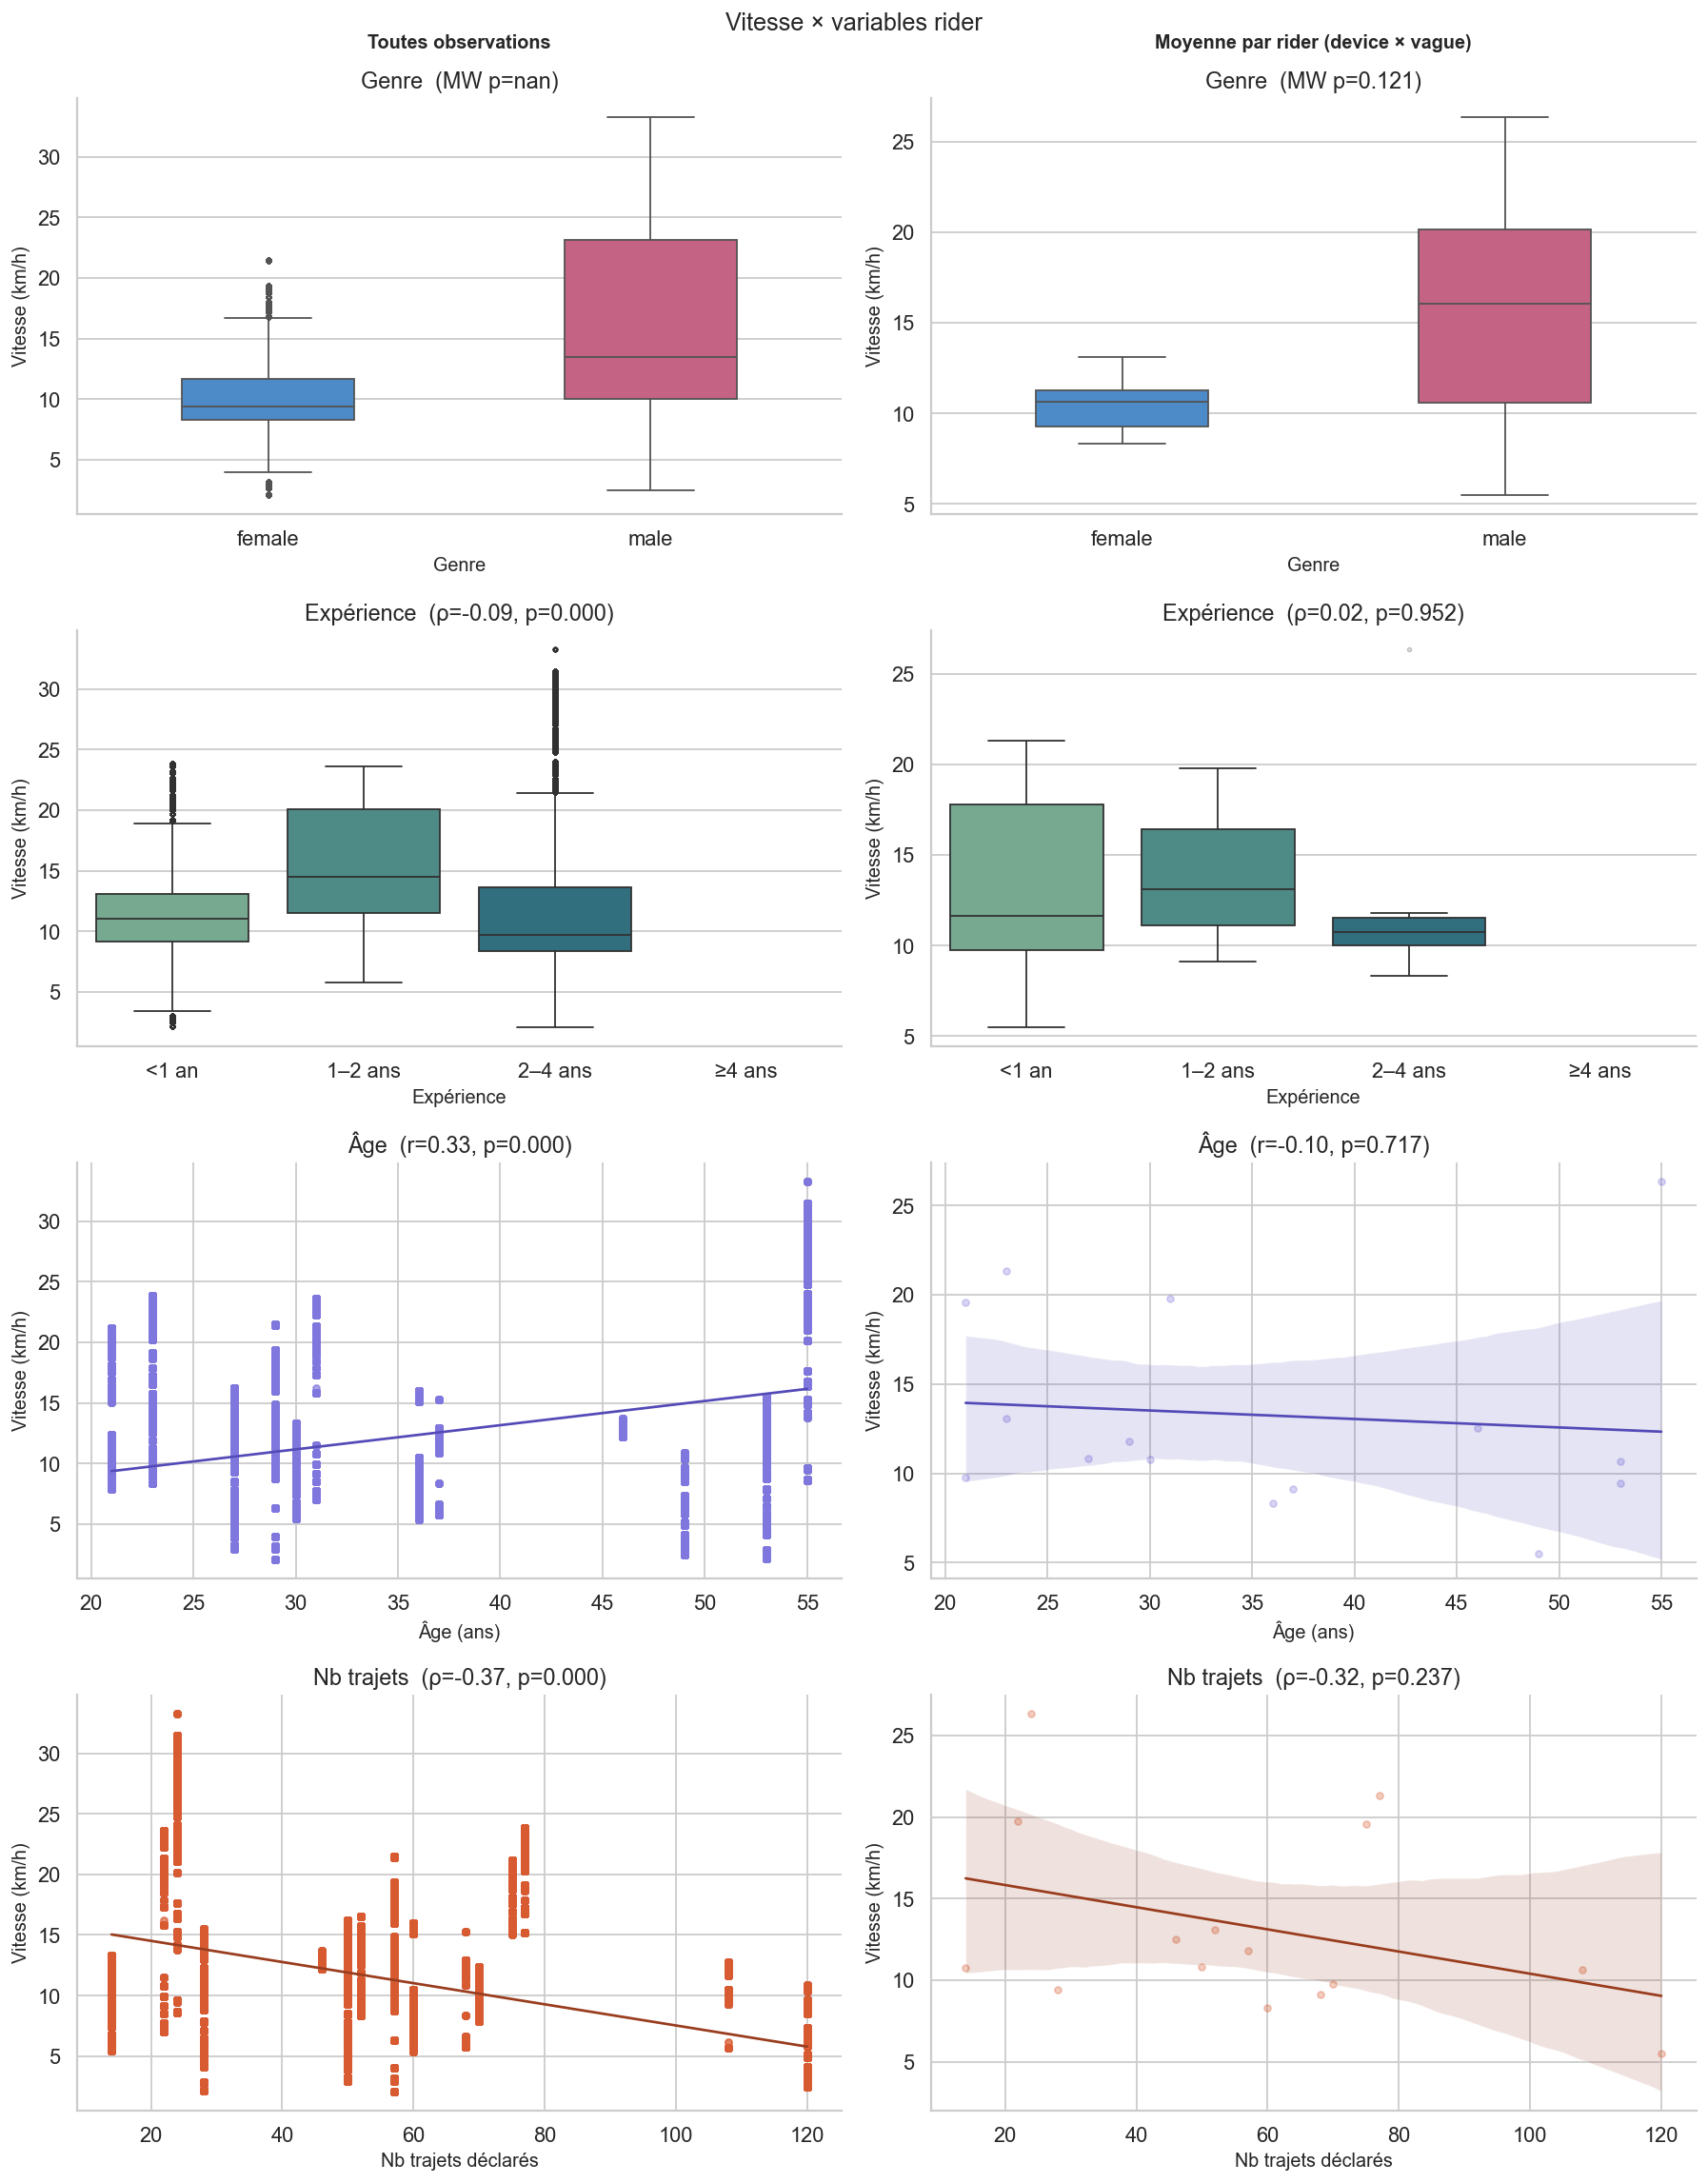


Corrélations de Spearman avec la vitesse
Variable             ρ (obs)   p (obs)   ρ (rider)   p (rider)
-----------------------------------------------------------------
  age               -0.055 ***     0.000     -0.251 ns       0.368
  experience_num    -0.091 ***     0.000     +0.017 ns       0.952
  nb_trajets        -0.366 ***     0.000     -0.325 ns       0.237
  distance_km       -0.132 ***     0.000     -0.154 ns       0.585


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ══════════════════════════════════════════════════════════════════════════════
# 0. Préparation des données rider
# ══════════════════════════════════════════════════════════════════════════════

exp_map = {
    "0.5-1": 0.75,
    "1-2":   1.5,
    ">2":    3.0,
    "<0.5":  0.25,
    "2-5":   3.5,
}

for col in ["age", "nb_trajets", "distance_km"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "experience" in df.columns:
    df["experience_num"] = df["experience"].map(exp_map)
    unmapped = df.loc[df["experience_num"].isna() & df["experience"].notna(),
                      "experience"].unique()
    if len(unmapped):
        print(f"⚠ Valeurs experience non mappées : {unmapped}")

# ── Niveau 1 : toutes les observations ───────────────────────────────────────
obs = df.copy()

# ── Niveau 2 : moyenne par rider (rider_id = device × vague) ─────────────────
rider_meta_cols = [c for c in ["genre", "age", "experience_num", "nb_trajets", "distance_km"]
                   if c in df.columns]

rider = (
    df.groupby(["rider_id"] + rider_meta_cols)["speed_kmh"]
    .mean()
    .reset_index()
    .rename(columns={"speed_kmh": "speed_mean"})
)

print(f"Observations totales     : {len(obs)}")
print(f"Riders uniques           : {rider['rider_id'].nunique()}")
print(f"Avec age renseigné       : {rider['age'].notna().sum()}")
print(f"Avec experience renseigné: {rider['experience_num'].notna().sum()}")
print(f"Genres présents          : {rider['genre'].dropna().unique()}")
print(rider[["rider_id", "genre", "age", "experience_num", "nb_trajets", "speed_mean"]].to_string())


# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════

def mannwhitney_title(data, group_col, val_col, base_title):
    groups = [g[val_col].values for _, g in data.dropna(subset=[group_col]).groupby(group_col)]
    if len(groups) == 2 and all(len(g) >= 2 for g in groups):
        _, p = stats.mannwhitneyu(*groups, alternative="two-sided")
        return f"{base_title}  (MW p={p:.3f})"
    return base_title

def spearman_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.spearmanr(sub["x"], sub["y"])
    return f"{base_title}  (ρ={r:.2f}, p={p:.3f})"

def pearson_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.pearsonr(sub["x"], sub["y"])
    return f"{base_title}  (r={r:.2f}, p={p:.3f})"


# ══════════════════════════════════════════════════════════════════════════════
# Plots — 4 variables × 2 niveaux = 8 axes (4 lignes × 2 colonnes)
# Colonne gauche  : toutes les observations
# Colonne droite  : moyenne par rider (rider_id)
# ══════════════════════════════════════════════════════════════════════════════

unique_genres = obs["genre"].dropna().unique()
palette_genre = dict(zip(sorted(unique_genres), ["#378ADD", "#D4537E", "#1D9E75", "#D85A30"]))

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle("Vitesse × variables rider", fontsize=14)

col_titles = ["Toutes observations", "Moyenne par rider (device × vague)"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(title, xy=(0.5, 1.12), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold")

# ── Ligne 1 : Genre ───────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[0],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sns.boxplot(data=data, x="genre", y=ycol,
                palette=palette_genre, width=0.45,
                flierprops={"markersize": 2, "alpha": 0.3}, ax=ax)
    ax.set_title(mannwhitney_title(data, "genre", ycol, "Genre"))
    ax.set_xlabel("Genre"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 2 : Expérience ──────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[1],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data.dropna(subset=["experience_num", ycol]).copy()
    if len(sub) >= 2:
        sub["exp_bin"] = pd.cut(sub["experience_num"],
                                bins=[0, 1, 2, 4, 99],
                                labels=["<1 an", "1–2 ans", "2–4 ans", "≥4 ans"],
                                right=False)
        sns.boxplot(data=sub, x="exp_bin", y=ycol,
                    palette="crest", ax=ax,
                    flierprops={"markersize": 2, "alpha": 0.3})
        ax.set_title(spearman_title(sub["experience_num"], sub[ycol], "Expérience"))
    else:
        ax.set_title(f"Expérience (n={len(sub)}, insuf.)")
    ax.set_xlabel("Expérience"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 3 : Âge ─────────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[2],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data[["age", ycol]].dropna()
    if len(sub) >= 2:
        sns.regplot(data=sub, x="age", y=ycol, ax=ax,
                    scatter_kws={"alpha": 0.3, "s": 15, "color": "#7F77DD"},
                    line_kws={"color": "#534AB7", "lw": 1.5})
        ax.set_title(pearson_title(sub["age"], sub[ycol], "Âge"))
    else:
        ax.set_title(f"Âge (n={len(sub)}, insuf.)")
    ax.set_xlabel("Âge (ans)"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 4 : Nb trajets ──────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[3],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data[["nb_trajets", ycol]].dropna()
    if len(sub) >= 2:
        sns.regplot(data=sub, x="nb_trajets", y=ycol, ax=ax,
                    scatter_kws={"alpha": 0.3, "s": 15, "color": "#D85A30"},
                    line_kws={"color": "#993C1D", "lw": 1.5})
        ax.set_title(spearman_title(sub["nb_trajets"], sub[ycol], "Nb trajets"))
    else:
        ax.set_title(f"Nb trajets (n={len(sub)}, insuf.)")
    ax.set_xlabel("Nb trajets déclarés"); ax.set_ylabel("Vitesse (km/h)")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Tableau de corrélations — les deux niveaux côte à côte
# ══════════════════════════════════════════════════════════════════════════════
print("\nCorrélations de Spearman avec la vitesse")
print(f"{'Variable':18s}  {'ρ (obs)':>8}  {'p (obs)':>8}  {'ρ (rider)':>10}  {'p (rider)':>10}")
print("-" * 65)

for v in ["age", "experience_num", "nb_trajets", "distance_km"]:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (rider, "speed_mean")]:
        if v not in data.columns:
            results.append(("n/a", "n/a"))
            continue
        sub = data[[v, ycol]].dropna()
        if len(sub) < 2:
            results.append((f"n={len(sub)}", "—"))
            continue
        r, p = stats.spearmanr(sub[v], sub[ycol])
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{r:+.3f} {sig}", f"{p:.3f}"))
    print(f"  {v:16s}  {results[0][0]:>10}  {results[0][1]:>8}  {results[1][0]:>12}  {results[1][1]:>10}")

✔ Colonnes temporelles présentes

Observations totales  : 877682
Trajets uniques       : 25
Distribution time_of_day (trajets) :
time_of_day
Morning      14
Afternoon     9
Night         1
Evening       1

Weekend vs weekday (trajets) :
is_weekend
False    21
True      4


/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/2754825902.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Jour", y=ycol, order=order,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/2754825902.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Jour", y=ycol, order=order,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_81556/2754825902.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data.dropna(subset=["time_of_day", ycol]),
/var/folders/y0/0nrj3m412p97818

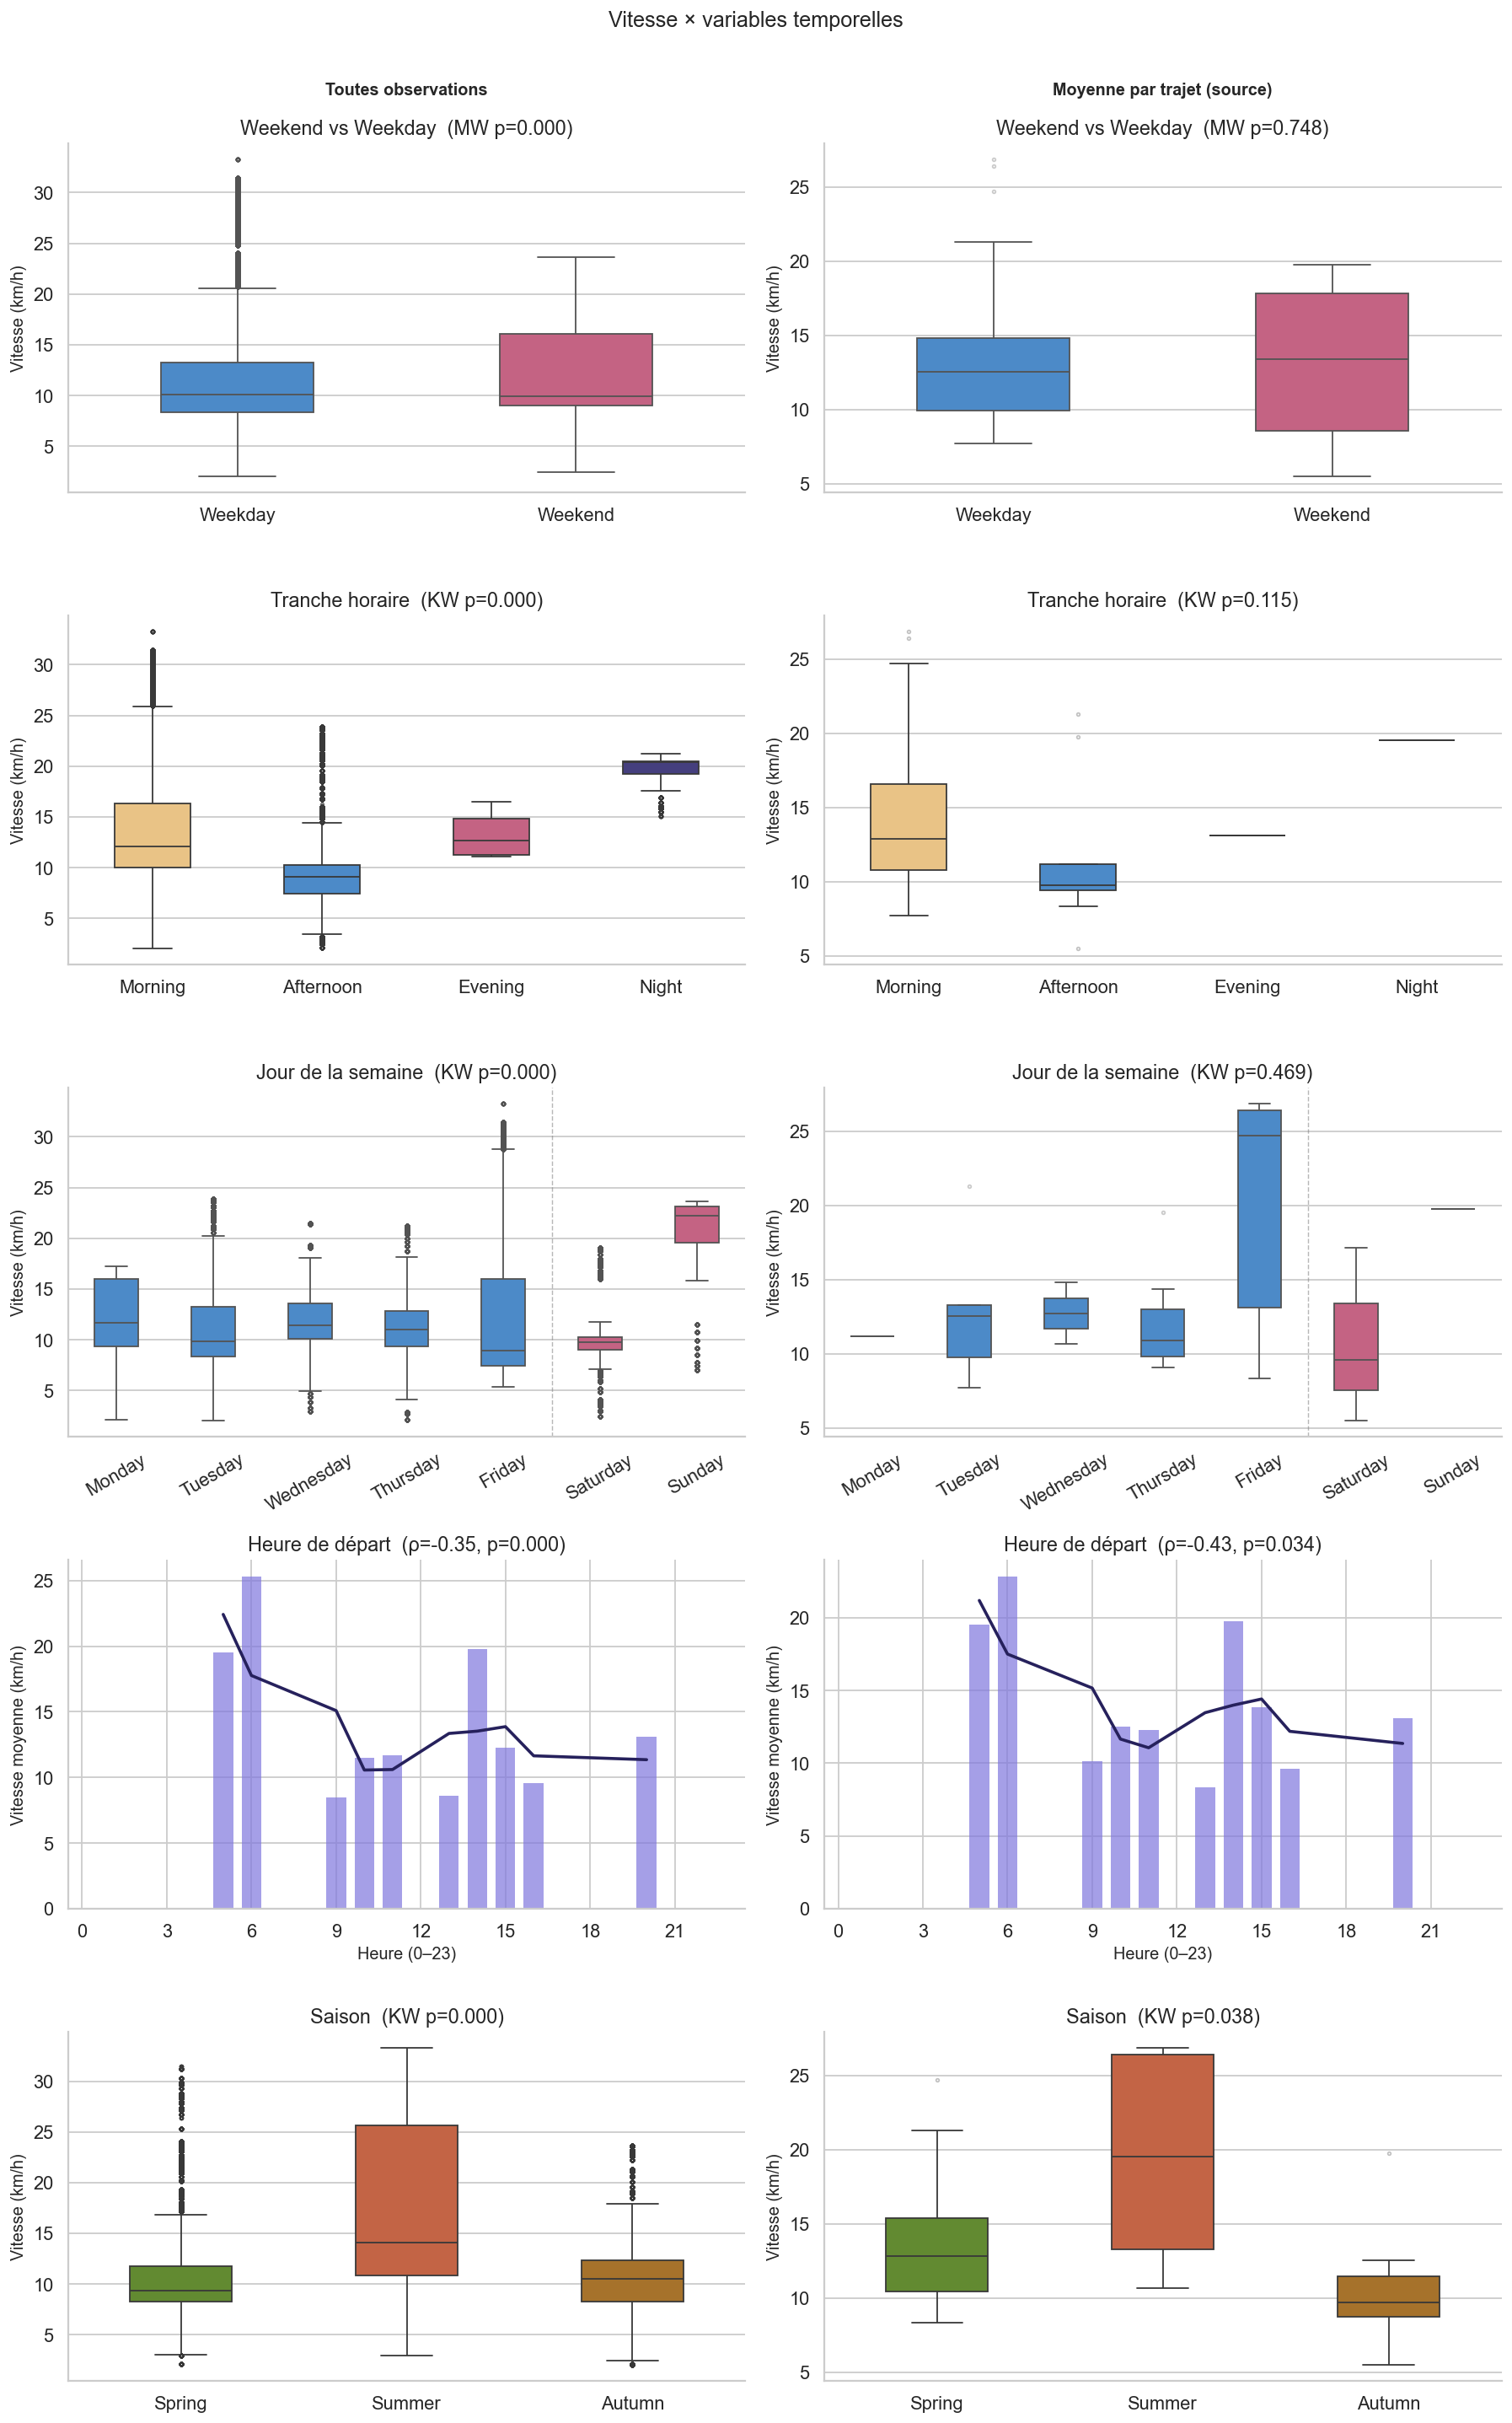

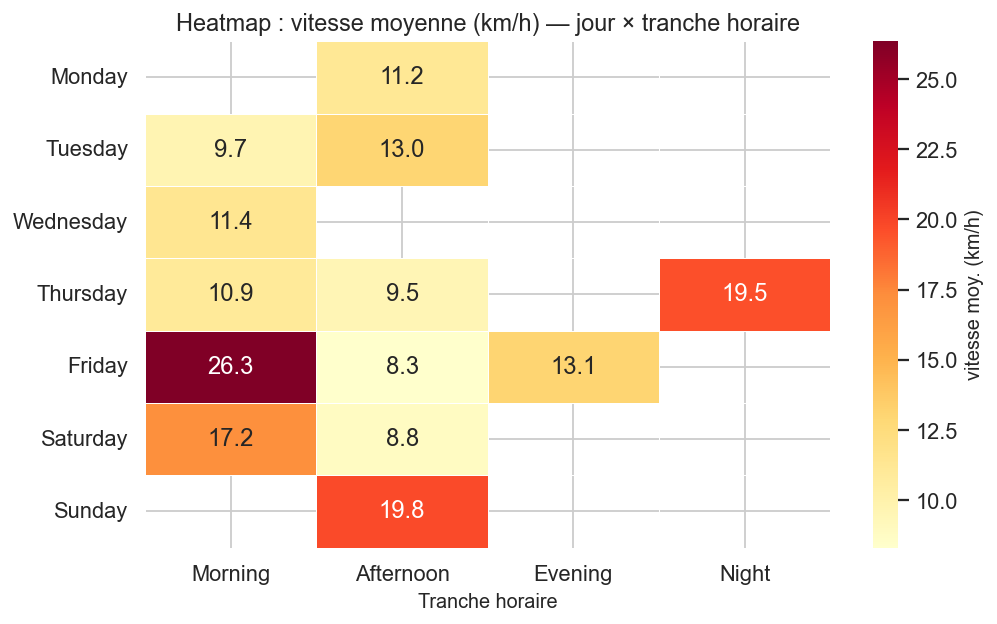


Tests statistiques — Vitesse × variables temporelles

Variable                        stat (obs)   p (obs)   stat (trip)    p (trip)
--------------------------------------------------------------------------------
  Weekday/Weekend  (MW)         39220163144.0 ***     0.000         47.0 ns       0.748
  Tranche horaire  (KW)         164200.2 ***     0.000         38.0 ns       0.123
  Jour semaine     (KW)          34952.1 ***     0.000          3.6 ns       0.469
  Saison           (KW)          99680.0 ***     0.000           6.6 *       0.038

Variable                           ρ (obs)   p (obs)      ρ (trip)    p (trip)
--------------------------------------------------------------------------------
  Heure départ     (Sp)           -0.350 ***     0.000        -0.426 *       0.034

Légende significance : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05
Tests : MW = Mann-Whitney, KW = Kruskal-Wallis, Sp = Spearman


In [59]:
# ══════════════════════════════════════════════════════════════════════════════
# Vitesse × variables temporelles
# ══════════════════════════════════════════════════════════════════════════════
# Prérequis : df chargé avec les colonnes issues de build_clean_dataset.py
# Nouvelles colonnes utilisées :
#   hour, day_of_week, day_name, is_weekend, time_of_day, month, season

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Vérification des colonnes temporelles disponibles ────────────────────────
TEMPORAL_COLS = ["hour", "day_of_week", "day_name", "is_weekend",
                 "time_of_day", "month", "season"]
missing = [c for c in TEMPORAL_COLS if c not in df.columns]
if missing:
    print(f"⚠ Colonnes temporelles manquantes : {missing}")
    print("  → Relancer build_clean_dataset.py pour les générer.")
else:
    print("✔ Colonnes temporelles présentes")

# ── Conversion de types ───────────────────────────────────────────────────────
for col in ["hour", "day_of_week", "month"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Niveau 1 : toutes les observations ───────────────────────────────────────
obs = df.copy()

# ── Niveau 2 : moyenne par trajet (source = un trajet e-scooter) ──────────────
# On utilise source comme unité d'agrégation car chaque trajet a un seul
# timestamp (is_weekend, time_of_day, etc. sont identiques par source).
temporal_meta = [c for c in TEMPORAL_COLS if c in df.columns]

trip = (
    df.groupby(["source"] + temporal_meta)["speed_kmh"]
    .mean()
    .reset_index()
    .rename(columns={"speed_kmh": "speed_mean"})
)

print(f"\nObservations totales  : {len(obs)}")
print(f"Trajets uniques       : {trip['source'].nunique()}")
if "time_of_day" in trip.columns:
    print(f"Distribution time_of_day (trajets) :\n"
          f"{trip['time_of_day'].value_counts(dropna=False).to_string()}")
if "is_weekend" in trip.columns:
    print(f"\nWeekend vs weekday (trajets) :\n"
          f"{trip['is_weekend'].value_counts(dropna=False).to_string()}")


# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════

def mannwhitney_title(data, group_col, val_col, base_title):
    groups = [g[val_col].dropna().values
              for _, g in data.dropna(subset=[group_col, val_col]).groupby(group_col)]
    if len(groups) == 2 and all(len(g) >= 2 for g in groups):
        _, p = stats.mannwhitneyu(*groups, alternative="two-sided")
        return f"{base_title}  (MW p={p:.3f})"
    return base_title

def kruskal_title(data, group_col, val_col, base_title):
    groups = [g[val_col].dropna().values
              for _, g in data.dropna(subset=[group_col, val_col]).groupby(group_col)]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        _, p = stats.kruskal(*groups)
        return f"{base_title}  (KW p={p:.3f})"
    return base_title

def spearman_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.spearmanr(sub["x"], sub["y"])
    return f"{base_title}  (ρ={r:.2f}, p={p:.3f})"


# ══════════════════════════════════════════════════════════════════════════════
# Palettes fixes
# ══════════════════════════════════════════════════════════════════════════════

# Ordre logique des tranches horaires
TOD_ORDER = ["Morning", "Afternoon", "Evening", "Night"]
TOD_COLORS = {
    "Morning":   "#FAC775",  # amber clair
    "Afternoon": "#378ADD",  # bleu
    "Evening":   "#D4537E",  # rose
    "Night":     "#3C3489",  # violet foncé
}

# Ordre logique des jours (lundi en premier)
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DOW_COLORS = (
    ["#378ADD"] * 5      # Lun–Ven : bleu
    + ["#D4537E"] * 2    # Sam–Dim : rose
)

SEASON_ORDER  = ["Spring", "Summer", "Autumn", "Winter"]
SEASON_COLORS = {"Spring": "#639922", "Summer": "#D85A30",
                 "Autumn": "#BA7517", "Winter": "#185FA5"}

WEEKEND_COLORS = {False: "#378ADD", True: "#D4537E"}


# ══════════════════════════════════════════════════════════════════════════════
# Figure principale — 5 lignes × 2 colonnes
# Col gauche : toutes les observations | Col droite : moyenne par trajet
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle("Vitesse × variables temporelles", fontsize=14, y=1.005)

col_titles = ["Toutes observations", "Moyenne par trajet (source)"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(title, xy=(0.5, 1.14), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold")

fp = {"markersize": 2, "alpha": 0.3}   # flierprops communs

# ── Ligne 0 : Weekend vs Weekday ──────────────────────────────────────────────
for ax, data, ycol in zip(axes[0], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "is_weekend" not in data.columns:
        ax.set_visible(False); continue
    d = data.dropna(subset=["is_weekend", ycol]).copy()
    d["Jour"] = d["is_weekend"].map({True: "Weekend", False: "Weekday"})
    order = ["Weekday", "Weekend"]
    palette = {"Weekday": "#378ADD", "Weekend": "#D4537E"}
    sns.boxplot(data=d, x="Jour", y=ycol, order=order,
                palette=palette, width=0.45, flierprops=fp, ax=ax)
    title = mannwhitney_title(d, "Jour", ycol, "Weekend vs Weekday")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 1 : Time of day ─────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[1], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "time_of_day" not in data.columns:
        ax.set_visible(False); continue
    present = [t for t in TOD_ORDER if t in data["time_of_day"].values]
    colors  = [TOD_COLORS[t] for t in present]
    sns.boxplot(data=data.dropna(subset=["time_of_day", ycol]),
                x="time_of_day", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "time_of_day", ycol, "Tranche horaire")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 2 : Jour de la semaine ─────────────────────────────────────────────
for ax, data, ycol in zip(axes[2], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "day_name" not in data.columns:
        ax.set_visible(False); continue
    present = [d for d in DOW_ORDER if d in data["day_name"].values]
    colors  = [DOW_COLORS[DOW_ORDER.index(d)] for d in present]
    sns.boxplot(data=data.dropna(subset=["day_name", ycol]),
                x="day_name", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "day_name", ycol, "Jour de la semaine")
    ax.set_title(title); ax.set_xlabel("")
    ax.set_ylabel("Vitesse (km/h)")
    ax.tick_params(axis="x", rotation=30)
    # Séparer visuellement weekend
    n_present_weekdays = sum(1 for d in present if d in DOW_ORDER[:5])
    if n_present_weekdays > 0 and any(d in present for d in DOW_ORDER[5:]):
        ax.axvline(n_present_weekdays - 0.5, color="#888", lw=0.8,
                   ls="--", alpha=0.6, label="weekend →")

# ── Ligne 3 : Heure de la journée (scatter + régression) ─────────────────────
for ax, data, ycol in zip(axes[3], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "hour" not in data.columns:
        ax.set_visible(False); continue
    sub = data[["hour", ycol]].dropna()
    if len(sub) >= 2:
        # Boîtes par heure (groupby)
        hourly = data.dropna(subset=["hour", ycol]).copy()
        hourly["hour_int"] = hourly["hour"].astype(int)
        means = hourly.groupby("hour_int")[ycol].mean()
        ax.bar(means.index, means.values, width=0.7,
               color="#7F77DD", alpha=0.7, linewidth=0)
        # Courbe lissée (rolling)
        smooth = means.sort_index().rolling(window=3, center=True, min_periods=1).mean()
        ax.plot(smooth.index, smooth.values, color="#26215C", lw=2)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.set_xlim(-0.5, 23.5)
        title = spearman_title(sub["hour"], sub[ycol], "Heure de départ")
        ax.set_title(title)
    else:
        ax.set_title(f"Heure (n={len(sub)}, insuf.)")
    ax.set_xlabel("Heure (0–23)"); ax.set_ylabel("Vitesse moyenne (km/h)")

# ── Ligne 4 : Saison ──────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[4], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "season" not in data.columns:
        ax.set_visible(False); continue
    present = [s for s in SEASON_ORDER if s in data["season"].values]
    colors  = [SEASON_COLORS[s] for s in present]
    sns.boxplot(data=data.dropna(subset=["season", ycol]),
                x="season", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "season", ycol, "Saison")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Heatmap : vitesse moyenne par jour × tranche horaire
# ══════════════════════════════════════════════════════════════════════════════

if "day_name" in obs.columns and "time_of_day" in obs.columns:
    heatmap_data = (
        obs.dropna(subset=["day_name", "time_of_day", "speed_kmh"])
        .groupby(["day_name", "time_of_day"])["speed_kmh"]
        .mean()
        .unstack("time_of_day")
        .reindex(index=DOW_ORDER, columns=TOD_ORDER)
    )
    if not heatmap_data.empty:
        fig2, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.3, cbar_kws={"label": "vitesse moy. (km/h)"},
                    ax=ax)
        ax.set_title("Heatmap : vitesse moyenne (km/h) — jour × tranche horaire")
        ax.set_xlabel("Tranche horaire"); ax.set_ylabel("")
        plt.tight_layout()
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Tableau de corrélations / tests — variables temporelles
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("Tests statistiques — Vitesse × variables temporelles")
print("=" * 70)

# Variables catégorielles : test de Kruskal-Wallis (ou Mann-Whitney si 2 groupes)
cat_vars = [
    ("is_weekend",  "Weekday/Weekend  (MW)"),
    ("time_of_day", "Tranche horaire  (KW)"),
    ("day_name",    "Jour semaine     (KW)"),
    ("season",      "Saison           (KW)"),
]

print(f"\n{'Variable':30s}  {'stat (obs)':>10}  {'p (obs)':>8}  {'stat (trip)':>12}  {'p (trip)':>10}")
print("-" * 80)

for col, label in cat_vars:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (trip, "speed_mean")]:
        if col not in data.columns:
            results.append(("n/a", "n/a")); continue
        groups = [g[ycol].dropna().values
                  for _, g in data.dropna(subset=[col, ycol]).groupby(col)]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) < 2:
            results.append((f"n<2", "—")); continue
        if len(groups) == 2:
            stat, p = stats.mannwhitneyu(*groups, alternative="two-sided")
            test_name = "MW"
        else:
            stat, p = stats.kruskal(*groups)
            test_name = "KW"
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{stat:.1f} {sig}", f"{p:.3f}"))
    print(f"  {label:28s}  {results[0][0]:>12}  {results[0][1]:>8}  "
          f"{results[1][0]:>14}  {results[1][1]:>10}")

# Variable continue : heure → Spearman
print(f"\n{'Variable':30s}  {'ρ (obs)':>10}  {'p (obs)':>8}  {'ρ (trip)':>12}  {'p (trip)':>10}")
print("-" * 80)

for col, label in [("hour", "Heure départ     (Sp)")]:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (trip, "speed_mean")]:
        if col not in data.columns:
            results.append(("n/a", "n/a")); continue
        sub = data[[col, ycol]].dropna()
        if len(sub) < 2:
            results.append((f"n={len(sub)}", "—")); continue
        r, p = stats.spearmanr(sub[col], sub[ycol])
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{r:+.3f} {sig}", f"{p:.3f}"))
    print(f"  {label:28s}  {results[0][0]:>12}  {results[0][1]:>8}  "
          f"{results[1][0]:>14}  {results[1][1]:>10}")

print("\nLégende significance : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05")
print("Tests : MW = Mann-Whitney, KW = Kruskal-Wallis, Sp = Spearman")